# Class 03 — Outlier Detection & Treatment · Encoding Categorical Variables



---

## Class Agenda

1. What is an outlier? Global vs contextual vs collective
2. **IQR** method (Tukey fences)
3. **Z-score** method (and modified Z-score with MAD)
4. Model-based detection — IsolationForest, LOF, EllipticEnvelope
5. Treatment methods — drop, cap (winsorize), transform, robust models
6. **Label encoding** — when ordinal, when dangerous
7. **One-hot encoding** — pros, cons, high-cardinality blowup
8. **Target (mean) encoding** — leakage-free with smoothing & CV
9. Production pipeline combining outlier handling + encoding


## Why This Topic Matters

**Importance in ML** — Outliers can dominate squared-loss training (one extreme point can flip a linear model's sign). Encoding determines whether a categorical feature contributes signal or noise.

**Importance in AI Systems** — Real-time pipelines must clip / cap incoming values; a single corrupt sensor reading can poison a daily retrain.

**Importance in Production ML** — Encoders are part of the model artifact. A *new* category at inference time will crash a naive `LabelEncoder`. Target encoding without CV is a leakage bug that ships to production undetected.

**Importance in Interviews** — Classic FAANG question: *"You have a `city` feature with 50k unique values — how do you encode it?"* The answer is a structured tour of OHE → target encoding → hashing → embeddings.

**Real-World Relevance** — Stripe Radar caps transaction amount features; Booking.com uses target encoding on `destination_city`; Netflix uses learned embeddings for `title_id`.


## Learning Outcomes

1. Define outliers and distinguish global, contextual, and collective anomalies.
2. Apply **IQR** (Tukey) and **Z-score** detection by hand and in code.
3. Use **IsolationForest** and **LOF** for multivariate detection.
4. Choose between drop / cap / transform / robust-model treatment.
5. Apply **Winsorization** at the right percentiles.
6. Decide when **Label / Ordinal / One-Hot / Target / Hashing** encoding is appropriate.
7. Implement **smoothed, CV-based target encoding** to avoid leakage.
8. Handle **unknown categories** at inference time.
9. Build a single leakage-free `Pipeline` combining outlier capping + encoding.
10. Reason about cardinality-vs-bias tradeoffs in encoding choice.


## 1. What Is an Outlier?

> A data point that is far from the rest of the data under the model you implicitly assume.

- **Global outlier** — extreme on a feature: a $1M house in a 100K-300K dataset.
- **Contextual outlier** — extreme *given a context*: 35°C is normal in July, an outlier in January.
- **Collective outlier** — a group of points jointly anomalous (e.g., a burst of identical micro-transactions = card-testing fraud).

> **Example.** In ride-share trips, a 4-hour `trip_duration` is global-outlier. A 4-hour trip within a city of 10 km² is *contextual* — likely a driver who forgot to end the trip.


C:\Users\athir\AppData\Local\Temp\ipykernel_3872\3332956130.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(x, vert=False); plt.title("Outliers visible in boxplot"); plt.show()


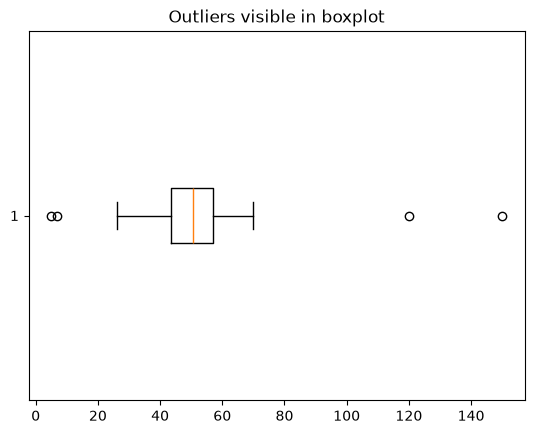

In [1]:
# Example — visualize outliers
import numpy as np, matplotlib.pyplot as plt
rng = np.random.default_rng(0)
x = np.r_[rng.normal(50, 10, 200), [5, 7, 120, 150]]
plt.boxplot(x, vert=False); plt.title("Outliers visible in boxplot"); plt.show()


## 2. IQR (Tukey Fences)

$$ Q_1, Q_3 = 25\text{th}, 75\text{th percentile}, \quad \text{IQR} = Q_3 - Q_1. $$

Flag $x$ as outlier if
$$ x < Q_1 - 1.5 \cdot \text{IQR} \quad \text{or} \quad x > Q_3 + 1.5 \cdot \text{IQR}. $$

**Distribution-free**, robust, works on skewed data. Use 3·IQR for "extreme" outliers.

> **Example.** Salaries with $Q_1 = 50k$, $Q_3 = 110k$, IQR = 60k → upper fence = $200k$. A $750k$ comp value is an outlier; a $190k$ value is not.


In [4]:
# Example — IQR detection
import numpy as np, pandas as pd, seaborn as sns
df = sns.load_dataset("tips")
def iqr_mask(s, k=1.5):
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    return (s < q1 - k*iqr) | (s > q3 + k*iqr)
mask = iqr_mask(df["total_bill"])
print(f"Outliers: {mask.sum()} / {len(df)}")
print(df.loc[mask, "total_bill"].sort_values().tolist())


Outliers: 9 / 244
[40.55, 41.19, 43.11, 44.3, 45.35, 48.17, 48.27, 48.33, 50.81]


## 3. Z-score & Modified Z-score

$$ z_i = \frac{x_i - \mu}{\sigma}, \qquad |z_i| > 3 \Rightarrow \text{outlier}. $$

Assumes (approximate) **Gaussianity**. Breaks on skewed/heavy-tailed data.

**Modified Z-score** (Iglewicz & Hoaglin) uses median and MAD — robust:

$$ M_i = \frac{0.6745\,(x_i - \tilde x)}{\text{MAD}}, \qquad \text{MAD} = \text{median}(|x_i - \tilde x|). $$

Flag $|M_i| > 3.5$.

> **Example.** Web latency (heavy right tail). Z-score declares ~5% outliers (over-flags). Modified Z-score flags ~0.5% — the real tail.


In [ ]:
# Example — Z vs Modified Z
import numpy as np
rng = np.random.default_rng(0)
x = np.r_[rng.normal(100, 15, 500), [400, 450, 500]]   # 3 true outliers
z = (x - x.mean()) / x.std()
mz = 0.6745 * (x - np.median(x)) / np.median(np.abs(x - np.median(x)))
print(f"|z|>3      flags: {(np.abs(z) > 3).sum()}")
print(f"|mZ|>3.5   flags: {(np.abs(mz) > 3.5).sum()}")


|z|>3      flags: 3
|mZ|>3.5   flags: 5


## 4. Model-Based Detection (multivariate)

- **IsolationForest** — random splits; anomalies isolate in fewer splits. $\mathcal{O}(n \log n)$, scales to millions of rows.
- **LOF (Local Outlier Factor)** — density relative to neighbors; finds *local* anomalies in dense regions.
- **EllipticEnvelope** — assumes Gaussian, fits robust covariance.

> **Example.** On credit transactions, IsolationForest flags multivariate anomalies (small amount + foreign IP + new device + 3am) that no single feature exceeds.


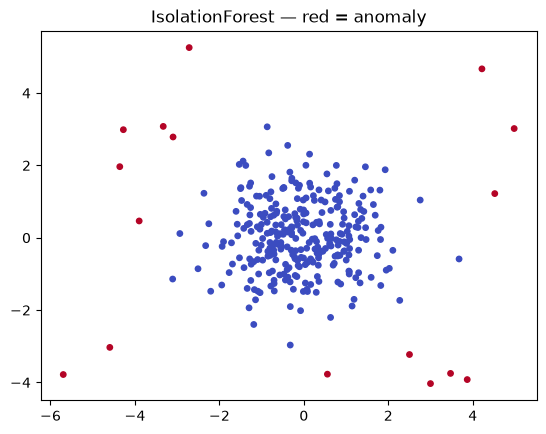

In [1]:
# Example — IsolationForest on 2D data
import numpy as np, matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
rng = np.random.default_rng(0)
X = np.r_[rng.normal(0, 1, (300, 2)), rng.uniform(-6, 6, (20, 2))]
iso = IsolationForest(contamination=0.05, random_state=0).fit(X)
pred = iso.predict(X)   # -1 = outlier
plt.scatter(X[:,0], X[:,1], c=(pred==-1), cmap="coolwarm", s=15)
plt.title("IsolationForest — red = anomaly"); plt.show()


## 5. Treatment Methods

| Method | When | Side effect |
|--------|------|-------------|
| **Drop** | MCAR, <2%, true errors | reduces $n$ |
| **Cap / Winsorize** (clip at p1/p99) | preserve sample size | distorts tails |
| **Log / Box-Cox transform** | right-skewed positive | changes interpretation |
| **Use a robust model** (HuberRegressor, GBM, tree) | when outliers are real | no preprocessing needed |
| **Bin into quantiles** | when only rank matters | loses precision |

> **Example.** House prices: cap at 99th percentile *and* log-transform, then fit Ridge — model becomes robust without dropping any luxury home.


In [ ]:
# Example — winsorization with scipy
import numpy as np
from scipy.stats.mstats import winsorize
x = np.r_[np.random.default_rng(0).normal(50, 10, 200), [500, 600]]
x_w = winsorize(x, limits=[0.01, 0.01])
print(f"Before: max={x.max():.1f}   After: max={x_w.max():.1f}")


Before: max=600.0   After: max=70.0


## 6. Label / Ordinal Encoding

**Label encoding** maps categories to integers 0..K-1.

- ✅ Safe for **tree-based models** (split on integer-equivalence is fine).
- ❌ Dangerous for linear models / KNN — implies an artificial *order* and *distance*.
- Use `OrdinalEncoder` when there is a real order (`S<M<L<XL`).

> **Example.** Encoding `country` with `LabelEncoder` for logistic regression: model learns "France (3) is closer to Germany (4) than to USA (180)" — pure noise. Use OHE or target encoding instead.


In [ ]:
# Example — OrdinalEncoder with explicit order
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
df = pd.DataFrame({"size": ["S", "L", "M", "XL", "M", "S"]})
enc = OrdinalEncoder(categories=[["S", "M", "L", "XL"]])
print(enc.fit_transform(df))


[[0.]
 [2.]
 [1.]
 [3.]
 [1.]
 [0.]]


## 7. One-Hot Encoding

Creates K (or K-1) binary columns. Safe for any model.

- ✅ Loss-less, no false ordering.
- ❌ Explodes with cardinality (`zip_code` → 40k columns); sparse matrices required.
- Use `drop="first"` for linear models to avoid the dummy-variable trap.
- Always pass `handle_unknown="ignore"` — production *will* see new categories.

> **Example.** `device_type` has 5 values → OHE is perfect. `user_id` has 10M values → OHE is impossible; use hashing or embeddings.


In [ ]:
# Example — OHE with unknown-category safety
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
train = pd.DataFrame({"city": ["NYC", "LA", "SF", "NYC"]})
test  = pd.DataFrame({"city": ["NYC", "BOS"]})       # BOS unseen
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(train)
print(enc.transform(test))   # BOS -> all zeros, no crash


[[0. 1. 0.]
 [0. 0. 0.]]


## 8. Target (Mean) Encoding

Replace each category with the **mean target** for that category.

$$ \hat{x}_c = \frac{n_c \cdot \bar y_c + m \cdot \bar y}{n_c + m} \qquad \text{(Bayesian smoothing)} $$

- $n_c$ — count of category $c$; $\bar y_c$ — mean target for $c$; $\bar y$ — global mean; $m$ — smoothing strength.
- Rare categories shrink toward the global mean.

**Leakage warning.** Naive target encoding on the full dataset leaks the target into features. Always compute encoding via **out-of-fold** means (or with sklearn ≥1.3 use the built-in `TargetEncoder`, which does internal CV).

> **Example.** Booking.com's `destination_city` has ~30k categories. Target-encoded with smoothing $m=20$: a city seen 5 times averages to "city behavior" pulled 4× toward the global rate.


In [ ]:
# Example — sklearn TargetEncoder (CV-internal, leakage-free)
import numpy as np, pandas as pd
from sklearn.preprocessing import TargetEncoder
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(0)
cities = rng.choice(["NYC","LA","SF","CHI","BOS","HOU","SEA","DC","ATL","DEN"], 2000)
y = (cities == "SF").astype(int) ^ (rng.random(2000) < 0.3)
df = pd.DataFrame({"city": cities})

Xtr, Xte, ytr, yte = train_test_split(df, y, test_size=.2, random_state=0)
te = TargetEncoder(smooth="auto", random_state=0).fit(Xtr, ytr)
print(pd.DataFrame({"city": Xte["city"].head(),
                    "encoded": te.transform(Xte).ravel()[:5]}))


     city   encoded
405   SEA  0.382797
1190  DEN  0.366266
1132  ATL  0.265071
731   NYC  0.271901
1754  CHI  0.260720


## 9. Combined Production Pipeline

Best practice: wrap **capping + imputing + encoding + model** in a single `Pipeline` so the entire transform is fit on train only and persisted as one artifact.


In [ ]:
# Example — production-style pipeline
import numpy as np, pandas as pd, seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (StandardScaler, OneHotEncoder,
                                   TargetEncoder, FunctionTransformer)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

df = sns.load_dataset("titanic").dropna(subset=["embarked"]).copy()
y = df["survived"]; X = df[["age","fare","pclass","sex","embarked"]]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.2, random_state=0)

# Cap fare at 99th percentile (computed inside the transformer)
def cap99(a):
    a = a.copy()
    for j in range(a.shape[1]):
        hi = np.nanpercentile(a[:, j], 99)
        a[:, j] = np.minimum(a[:, j], hi)
    return a
capper = FunctionTransformer(cap99, validate=False)

num = ["age", "fare", "pclass"]; low_card = ["sex", "embarked"]
pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("cap", capper),
                      ("sc",  StandardScaler())]), num),
    ("ohe", OneHotEncoder(handle_unknown="ignore"), low_card),
])
model = Pipeline([("pre", pre),
                  ("lr", LogisticRegression(max_iter=1000))]).fit(Xtr, ytr)
print(f"Test accuracy: {model.score(Xte, yte):.3f}")


Test accuracy: 0.719


## Tradeoffs & Pitfalls

- Aggressive outlier dropping changes the population the model represents.
- Target encoding without CV → leakage (train AUC inflated by 5–15 pts).
- OHE on `user_id`-style features blows up memory; switch to hashing or embeddings.
- Label-encoding nominal columns into linear models silently corrupts predictions.
- Capping at static percentiles → distribution drift makes the cap obsolete; recompute per retrain.

## Production Considerations

- Persist encoder + cap thresholds as part of the model artifact.
- Log incoming categorical cardinality; alert if new categories exceed 1% of traffic.
- For very-high cardinality, prefer hashing (`FeatureHasher`) or learned embeddings.

